## Country Level Exploratory Analysis

This notebook examines the raw JKP Global Factor Data emerging markets panel
to understand the country level composition of the cross section, the monthly
firm counts per country, and the distribution of missing data across countries.
The objective is to determine whether a subset of countries can be excluded to
bring the full cross section within a tractable max_firms threshold.

### 1. Setup and Configuration

In [1]:
import gc
import json
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RAW_PATH = Path("../data/Global Factor_EM.parquet")
print(f"Raw data path: {RAW_PATH}")
print(f"File exists: {RAW_PATH.exists()}")

Raw data path: ..\data\Global Factor_EM.parquet
File exists: True


In [2]:
id_cols = ["id", "gvkey", "iid", "eom", "excntry"]
df_ids = pd.read_parquet(RAW_PATH, columns = id_cols)

print(f"Total observations: {len(df_ids):,}")
print(f"Date range: {df_ids['eom'].min()} to {df_ids['eom'].max()}")
print(f"Unique countries: {df_ids['excntry'].nunique()}")
print(f"Unique firms (by id): {df_ids['id'].nunique():,}")
print()
print("Countries present:")
print(sorted(df_ids["excntry"].unique()))

Total observations: 4,386,856
Date range: 1995-01-31 to 2025-12-31
Unique countries: 24
Unique firms (by id): 30,385

Countries present:
['ARE', 'BRA', 'CHL', 'CHN', 'COL', 'CZE', 'EGY', 'GRC', 'HUN', 'IDN', 'IND', 'KOR', 'KWT', 'MEX', 'MYS', 'PER', 'PHL', 'POL', 'QAT', 'SAU', 'THA', 'TUR', 'TWN', 'ZAF']


### Different Firms per Country

In [3]:
firms_per_country = (
	df_ids.groupby("excntry")["id"]
	.nunique()
	.sort_values(ascending = False)
	.reset_index()
	.rename(columns = {"id": "unique_firms"})
)

total_firms = firms_per_country["unique_firms"].sum()
firms_per_country["pct_of_total"] = (firms_per_country["unique_firms"] / total_firms * 100).round(2)
firms_per_country["cumulative_pct"] = firms_per_country["pct_of_total"].cumsum().round(2)

print(f"{'Country':<10} {'Unique Firms':>14} {'% of Total':>12} {'Cumulative %':>14}")
print()
for _, row in firms_per_country.iterrows():
	print(f"{row['excntry']:<10} {row['unique_firms']:>14,} {row['pct_of_total']:>11.2f}% {row['cumulative_pct']:>13.2f}%")
print()
print(f"{'Total':<10} {total_firms:>14,}")

Country      Unique Firms   % of Total   Cumulative %

IND                 6,829       22.47%         22.47%
CHN                 5,500       18.10%         40.57%
KOR                 4,052       13.34%         53.91%
TWN                 2,971        9.78%         63.69%
MYS                 1,617        5.32%         69.01%
POL                 1,309        4.31%         73.32%
THA                 1,265        4.16%         77.48%
IDN                 1,103        3.63%         81.11%
ZAF                 1,070        3.52%         84.63%
TUR                   742        2.44%         87.07%
GRC                   449        1.48%         88.55%
BRA                   429        1.41%         89.96%
CZE                   414        1.36%         91.32%
SAU                   411        1.35%         92.67%
PHL                   359        1.18%         93.85%
EGY                   321        1.06%         94.91%
MEX                   297        0.98%         95.89%
CHL                   294  

### Maximum Firms per Month per Country

For each country, we compute the maximum number of firms observed in any
single month. This determines the peak cross section size and is the
binding constraint for the max_firms parameter.

In [4]:
monthly_counts = (
	df_ids.groupby(["excntry", "eom"])["id"].nunique()
	.reset_index().rename(columns = {"id": "n_firms"})
)

country_monthly_stats = (
	monthly_counts.groupby("excntry")["n_firms"]
	.agg(["max", "mean", "median", "min"])
	.sort_values("max", ascending = False).reset_index()
)
country_monthly_stats.columns = ["excntry", "max_firms_month", "mean_firms_month", "median_firms_month", "min_firms_month"]
country_monthly_stats["mean_firms_month"] = country_monthly_stats["mean_firms_month"].round(0).astype(int)
country_monthly_stats["median_firms_month"] = country_monthly_stats["median_firms_month"].round(0).astype(int)

print(f"{'Country':<10} {'Max':>8} {'Mean':>8} {'Median':>8} {'Min':>8}")
print()
for _, row in country_monthly_stats.iterrows():
	print(f"{row['excntry']:<10} {row['max_firms_month']:>8,} {row['mean_firms_month']:>8,} {row['median_firms_month']:>8,} {row['min_firms_month']:>8,}")

Country         Max     Mean   Median      Min

IND           5,200    2,302    2,120      229
CHN           5,106    2,148    1,814       57
KOR           2,680    1,607    1,764      201
TWN           2,290    1,351    1,528      281
MYS           1,053      845      910      386
THA             897      558      512      305
IDN             879      422      339      161
POL             826      450      442       22
TUR             587      328      308       99
ZAF             540      328      300      205
SAU             386      151      156        1
GRC             333      198      172       49
CZE             279       53       18       10
BRA             271      137      159       15
PHL             262      205      202       82
EGY             218      147      164        3
KWT             188      142      157        1
CHL             184      141      143       50
ARE             151       82       85        1
MEX             128       99       96       53
PER         

### Total Cross Section Size per Month

We compute the total number of firms across all countries for each month.
This reveals the peak cross section that max_firms must accommodate.

Peak cross section size: 21,645 firms
Mean cross section size: 11,793 firms
Median cross section size: 11,661 firms
Month of peak: 2025-12-31


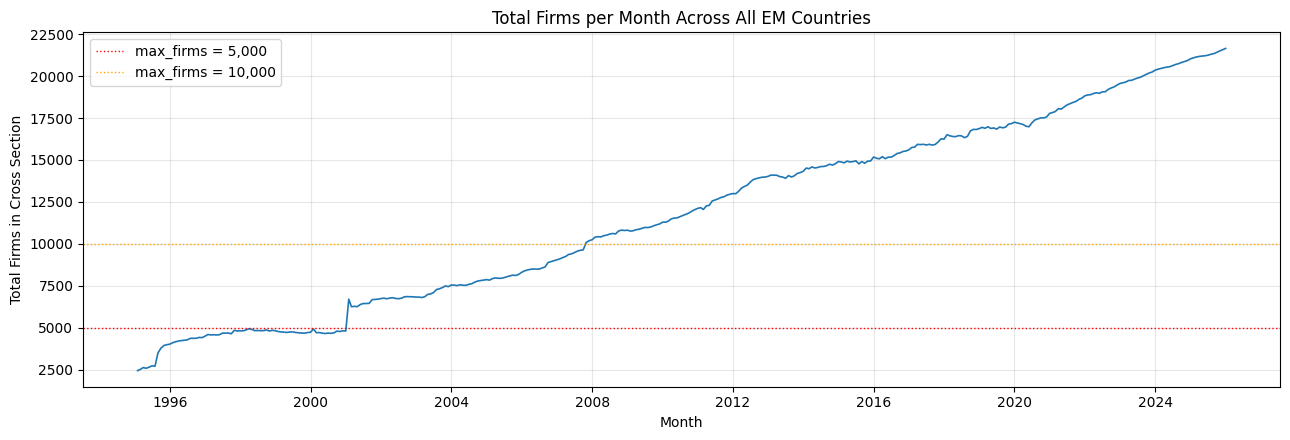

In [5]:
total_per_month = (
	monthly_counts.groupby("eom")["n_firms"]
	.sum().reset_index()
	.rename(columns = {"n_firms": "total_firms"})
)

print(f"Peak cross section size: {total_per_month['total_firms'].max():,} firms")
print(f"Mean cross section size: {total_per_month['total_firms'].mean():,.0f} firms")
print(f"Median cross section size: {total_per_month['total_firms'].median():,.0f} firms")
print(f"Month of peak: {total_per_month.loc[total_per_month['total_firms'].idxmax(), 'eom']}")

fig, ax = plt.subplots(figsize = (13, 4.5))
ax.plot(pd.to_datetime(total_per_month["eom"]), total_per_month["total_firms"], linewidth = 1.2)
ax.axhline(y = 5000, color = "red", linestyle = ":", linewidth = 1, label = "max_firms = 5,000")
ax.axhline(y = 10000, color = "orange", linestyle = ":", linewidth = 1, label = "max_firms = 10,000")
ax.set_xlabel("Month")
ax.set_ylabel("Total Firms in Cross Section")
ax.set_title("Total Firms per Month Across All EM Countries")
ax.legend()
ax.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

### Missing Data Analysis by Country

We now load the characteristic columns alongside the country identifier to
compute per country missingness rates. To manage memory, we read only the
characteristic columns that survived the preprocessing column filter.

In [6]:
# Load the column list from the preprocessing pipeline
with open("../jsons/train_columns.json", "r") as f:
	pipeline_cols = json.load(f)

# Extract original characteristic names (before lags and flags)
miss_flags = [c for c in pipeline_cols if c.endswith("_miss")]
char_bases = sorted(set(c.replace("_miss", "") for c in miss_flags))

# Read only characteristics + identifiers from raw data
raw_cols_available = pd.read_parquet(RAW_PATH, columns = []).columns.tolist()
chars_in_raw = [c for c in char_bases if c in raw_cols_available]
read_cols = ["id", "eom", "excntry"] + chars_in_raw

print(f"Characteristics to analyse: {len(chars_in_raw)}")
print(f"Reading {len(read_cols)} columns from raw data...")

df_miss = pd.read_parquet(RAW_PATH, columns = read_cols)
print(f"Loaded: {len(df_miss):,} rows")

Characteristics to analyse: 0
Reading 3 columns from raw data...
Loaded: 4,386,856 rows


#### Mean Missingness Rate per Country

In [7]:
# Compute per-row missing fraction across characteristics
char_data = df_miss[chars_in_raw]
df_miss["miss_frac"] = char_data.isnull().sum(axis = 1) / len(chars_in_raw)

country_miss = (
	df_miss.groupby("excntry")["miss_frac"]
	.agg(["mean", "median", "std"])
	.sort_values("mean", ascending = False).reset_index()
)
country_miss.columns = ["excntry", "mean_miss_rate", "median_miss_rate", "std_miss_rate"]

print(f"{'Country':<10} {'Mean Miss %':>12} {'Median Miss %':>14} {'Std':>8}")
print()
for _, row in country_miss.iterrows():
	print(
		f"{row['excntry']:<10}"
		f" {row['mean_miss_rate']*100:>11.2f}%"
		f" {row['median_miss_rate']*100:>13.2f}%"
		f" {row['std_miss_rate']:>8.4f}"
	)

Country     Mean Miss %  Median Miss %      Std

ARE                nan%           nan%      nan
BRA                nan%           nan%      nan
CHL                nan%           nan%      nan
CHN                nan%           nan%      nan
COL                nan%           nan%      nan
CZE                nan%           nan%      nan
EGY                nan%           nan%      nan
GRC                nan%           nan%      nan
HUN                nan%           nan%      nan
IDN                nan%           nan%      nan
IND                nan%           nan%      nan
KOR                nan%           nan%      nan
KWT                nan%           nan%      nan
MEX                nan%           nan%      nan
MYS                nan%           nan%      nan
PER                nan%           nan%      nan
PHL                nan%           nan%      nan
POL                nan%           nan%      nan
QAT                nan%           nan%      nan
SAU                nan%           nan% 

#### Proportion of Heavily Missing Observations per Country

We define a heavily missing observation as one where more than one third
of characteristics are null, consistent with the exclusion threshold
discussed in the proposal methodology.

In [8]:
df_miss["heavily_missing"] = df_miss["miss_frac"] > (1.0 / 3.0)

heavy_miss_by_country = (
	df_miss.groupby("excntry")
	.agg(
		total_obs = ("id", "count"),
		heavy_miss_obs = ("heavily_missing", "sum"),
	)
	.reset_index()
)
heavy_miss_by_country["heavy_miss_pct"] = (
	heavy_miss_by_country["heavy_miss_obs"] / heavy_miss_by_country["total_obs"] * 100
).round(2)
heavy_miss_by_country = heavy_miss_by_country.sort_values("heavy_miss_pct", ascending = False)

print(f"{'Country':<10} {'Total Obs':>12} {'Heavy Miss Obs':>16} {'Heavy Miss %':>14}")
print()
for _, row in heavy_miss_by_country.iterrows():
	print(
		f"{row['excntry']:<10} {int(row['total_obs']):>12,}"
		f" {int(row['heavy_miss_obs']):>16,} {row['heavy_miss_pct']:>13.2f}%"
	)

Country       Total Obs   Heavy Miss Obs   Heavy Miss %

ARE              24,356                0          0.00%
BRA              50,866                0          0.00%
CHL              52,277                0          0.00%
CHN             799,212                0          0.00%
COL              13,846                0          0.00%
CZE              19,758                0          0.00%
EGY              51,366                0          0.00%
GRC              73,634                0          0.00%
HUN              14,550                0          0.00%
IDN             156,888                0          0.00%
IND             856,338                0          0.00%
KOR             597,768                0          0.00%
KWT              42,460                0          0.00%
MEX              36,936                0          0.00%
MYS             314,252                0          0.00%
PER              26,728                0          0.00%
PHL              76,146                0       

In [9]:
# Merge country stats together
summary = firms_per_country.merge(country_monthly_stats, on = "excntry")
summary = summary.merge(country_miss[["excntry", "mean_miss_rate"]], on = "excntry")
summary = summary.merge(
	heavy_miss_by_country[["excntry", "heavy_miss_pct"]], on = "excntry"
)
summary = summary.sort_values("max_firms_month", ascending = False)

# Compute peak cross-section if each country is progressively excluded
# Strategy: drop countries with highest peak monthly firm count first
all_countries = summary["excntry"].tolist()
thresholds = [5000, 8000, 10000, 12000, 15000]

print("Progressive country exclusion (dropping largest peak contributors first)")
print()
print(f"{'Countries Dropped':<40} {'Remaining':>10} {'Peak Firms':>12} {'Mean Miss %':>12}")

dropped = []
for i in range(len(all_countries) + 1):
	remaining_countries = [c for c in all_countries if c not in dropped]
	if len(remaining_countries) == 0:
		break

	# Compute peak cross-section with remaining countries
	mask = monthly_counts["excntry"].isin(remaining_countries)
	peak = monthly_counts[mask].groupby("eom")["n_firms"].sum().max()

	# Mean missingness of remaining countries (weighted by observations)
	remaining_miss = df_miss[df_miss["excntry"].isin(remaining_countries)]["miss_frac"].mean()

	drop_label = ", ".join(dropped) if dropped else "(none)"
	if len(drop_label) > 38:
		drop_label = drop_label[:35] + "..."

	print(
		f"{drop_label:<40} {len(remaining_countries):>9}"
		f" {peak:>12,} {remaining_miss*100:>11.2f}%"
	)

	if i < len(all_countries):
		dropped.append(all_countries[i])

Progressive country exclusion (dropping largest peak contributors first)

Countries Dropped                         Remaining   Peak Firms  Mean Miss %
(none)                                          24       21,645         nan%
IND                                             23       16,445         nan%
IND, CHN                                        22       11,339         nan%
IND, CHN, KOR                                   21        8,659         nan%
IND, CHN, KOR, TWN                              20        6,369         nan%
IND, CHN, KOR, TWN, MYS                         19        5,316         nan%
IND, CHN, KOR, TWN, MYS, THA                    18        4,419         nan%
IND, CHN, KOR, TWN, MYS, THA, IDN               17        3,551         nan%
IND, CHN, KOR, TWN, MYS, THA, IDN, POL          16        2,888         nan%
IND, CHN, KOR, TWN, MYS, THA, IDN, ...          15        2,302         nan%
IND, CHN, KOR, TWN, MYS, THA, IDN, ...          14        2,096         nan%
I

In [10]:
target_max_firms = 10000

# Sort countries by their contribution to peak months
# Use max monthly firm count as the sorting criterion
candidates = summary.sort_values("max_firms_month", ascending = False)

dropped_for_target = []
remaining = set(all_countries)

current_peak = monthly_counts.groupby("eom")["n_firms"].sum().max()
print(f"Starting peak: {current_peak:,} firms across {len(remaining)} countries")
print(f"Target: {target_max_firms:,} firms")
print()

for _, row in candidates.iterrows():
	if current_peak <= target_max_firms:
		break
	country = row["excntry"]
	remaining.discard(country)
	dropped_for_target.append(country)

	mask = monthly_counts["excntry"].isin(remaining)
	current_peak = monthly_counts[mask].groupby("eom")["n_firms"].sum().max()

	print(
		f"Drop {country:<6} (max {int(row['max_firms_month']):>5,}/month, "
		f"miss rate {row['mean_miss_rate']*100:.1f}%) "
		f"=> peak now {current_peak:,} firms, {len(remaining)} countries remain"
	)

print()
if current_peak <= target_max_firms:
	print(f"Target achieved: peak {current_peak:,} firms with {len(remaining)} countries")
	print(f"Countries dropped ({len(dropped_for_target)}): {', '.join(dropped_for_target)}")
	print(f"Countries retained ({len(remaining)}): {', '.join(sorted(remaining))}")
else:
	print(f"Could not reach target. Current peak: {current_peak:,}")

Starting peak: 21,645 firms across 24 countries
Target: 10,000 firms

Drop IND    (max 5,200/month, miss rate nan%) => peak now 16,445 firms, 23 countries remain
Drop CHN    (max 5,106/month, miss rate nan%) => peak now 11,339 firms, 22 countries remain
Drop KOR    (max 2,680/month, miss rate nan%) => peak now 8,659 firms, 21 countries remain

Target achieved: peak 8,659 firms with 21 countries
Countries dropped (3): IND, CHN, KOR
Countries retained (21): ARE, BRA, CHL, COL, CZE, EGY, GRC, HUN, IDN, KWT, MEX, MYS, PER, PHL, POL, QAT, SAU, THA, TUR, TWN, ZAF


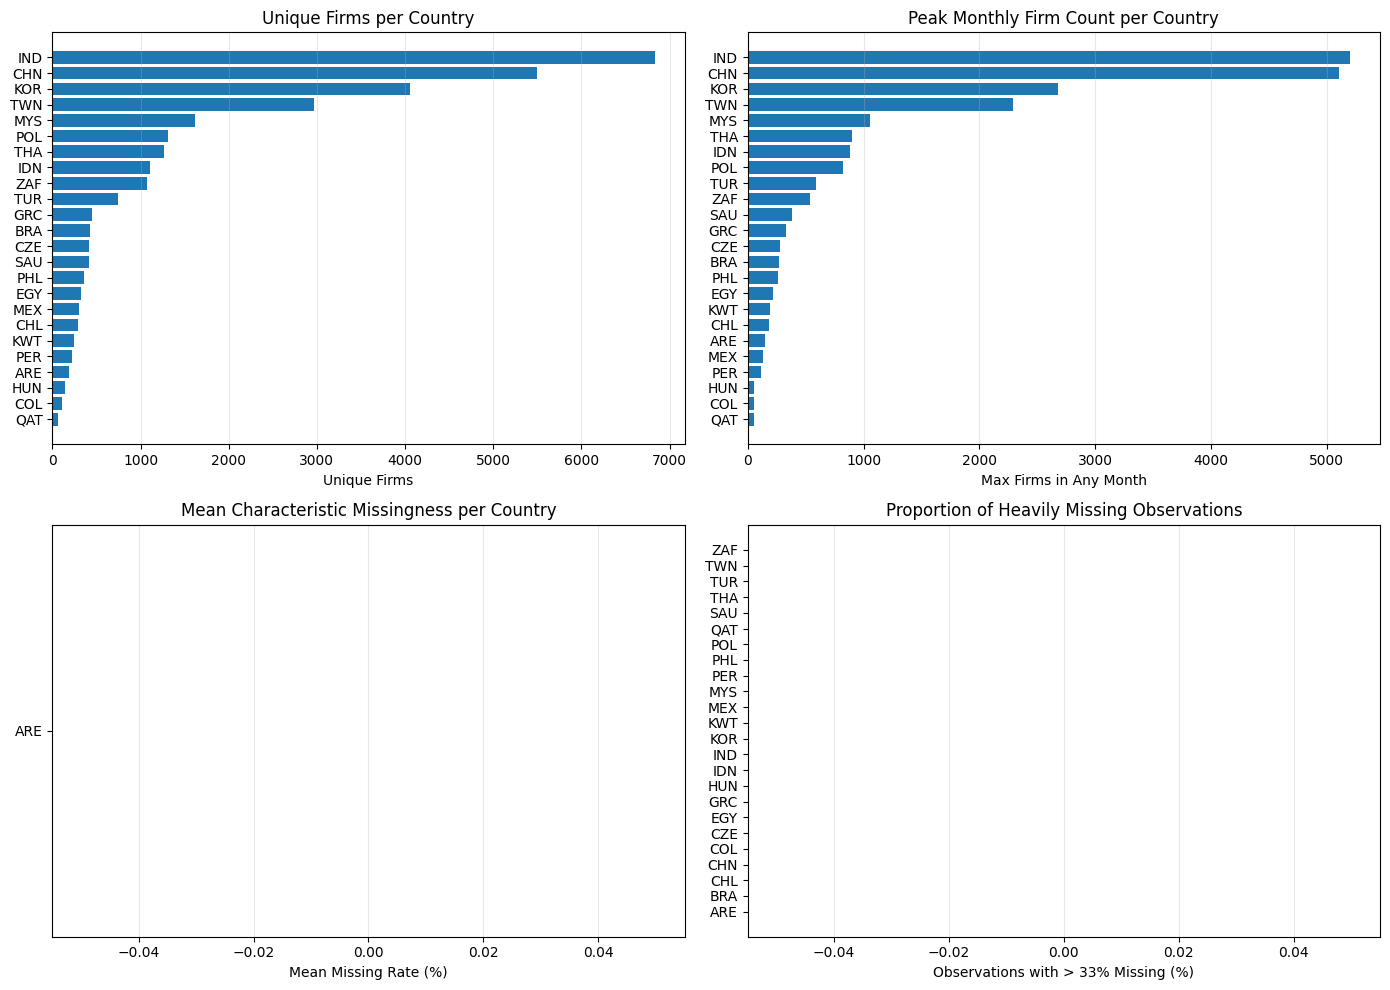

In [11]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

# 9a. Unique firms per country
ax = axes[0, 0]
plot_data = firms_per_country.sort_values("unique_firms", ascending = True)
ax.barh(plot_data["excntry"], plot_data["unique_firms"])
ax.set_xlabel("Unique Firms")
ax.set_title("Unique Firms per Country")
ax.grid(axis = "x", alpha = 0.3)

# 9b. Max firms per month per country
ax = axes[0, 1]
plot_data = country_monthly_stats.sort_values("max_firms_month", ascending = True)
ax.barh(plot_data["excntry"], plot_data["max_firms_month"])
ax.set_xlabel("Max Firms in Any Month")
ax.set_title("Peak Monthly Firm Count per Country")
ax.grid(axis = "x", alpha = 0.3)

# 9c. Mean missingness rate per country
ax = axes[1, 0]
plot_data = country_miss.sort_values("mean_miss_rate", ascending = True)
ax.barh(plot_data["excntry"], plot_data["mean_miss_rate"] * 100)
ax.set_xlabel("Mean Missing Rate (%)")
ax.set_title("Mean Characteristic Missingness per Country")
ax.grid(axis = "x", alpha = 0.3)

# 9d. Heavy missingness proportion per country
ax = axes[1, 1]
plot_data = heavy_miss_by_country.sort_values("heavy_miss_pct", ascending = True)
ax.barh(plot_data["excntry"], plot_data["heavy_miss_pct"])
ax.set_xlabel("Observations with > 33% Missing (%)")
ax.set_title("Proportion of Heavily Missing Observations")
ax.grid(axis = "x", alpha = 0.3)

plt.tight_layout()
plt.show()

In [12]:
del df_ids, df_miss, char_data, monthly_counts
gc.collect()

64